In [2]:
%matplotlib widget

import numpy as np
import datetime as dt
import spiceypy as spice
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

Delta distance SolO: 95903252.24847092 km
Delta time SolO: 59.199538424982045 hours
Date2 SolO: 2025-03-28 15:48:01.661670

Delta distance SolO: 94845554.32401991 km
Delta time SolO: 58.54663847161723 hours
Date2 SolO: 2025-03-28 16:27:12.101502

Delta distance SolO: 94865270.93748245 km
Delta time SolO: 58.558809220668174 hours
Date2 SolO: 2025-03-28 16:26:28.286806

Delta distance SolO: 94864903.49481392 km
Delta time SolO: 58.55858240420612 hours
Date2 SolO: 2025-03-28 16:26:29.103345

Delta distance PSP: 87630232.33219844 km
Delta time PSP: 54.0927360075299 hours
Date2 PSP: 2025-03-28 20:54:26.150373

Delta distance PSP: 97459735.22492236 km
Delta time PSP: 60.16033038575454 hours
Date2 PSP: 2025-03-28 14:50:22.810611

Delta distance PSP: 98671479.05566958 km
Delta time PSP: 60.908320404734305 hours
Date2 PSP: 2025-03-28 14:05:30.046543

Delta distance PSP: 98822556.02772069 km
Delta time PSP: 61.001577794889315 hours
Date2 PSP: 2025-03-28 13:59:54.319938

Delta distance PSP: 98841

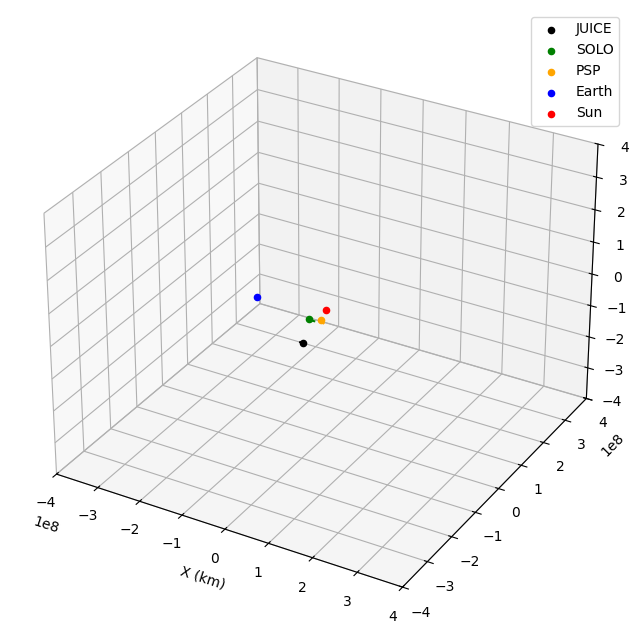

In [2]:
# Looking at the angular separation between JUICE and Solar Orbiter and PSP

spice.furnsh("../SPICE/Solar_Orbiter/kernels/mk/solo_ANC_soc-flown-mk_v111_20250425_002.tm")
spice.furnsh("../SPICE/JUICE/kernels/mk/juice_ops.tm")
spice.furnsh("../SPICE/psp.bsp")

date1 = "2025-03-31T03:00:00"
et1 = spice.str2et(date1)

# Get the positions of the three spacecraft on 31/03/2025 at 03:00:00
pos_juice, _ = spice.spkpos("JUICE", et1, "ECLIPJ2000", "NONE", "SUN")
pos_solo, _ = spice.spkpos("SOLAR ORBITER", et1, "ECLIPJ2000", "NONE", "SUN")
pos_psp, _ = spice.spkpos("SPP", et1, "ECLIPJ2000", "NONE", "SUN")

distance_juice = np.linalg.norm(pos_juice)
distance_solo = np.linalg.norm(pos_solo)
distance_psp = np.linalg.norm(pos_psp)

sw_speed = 450  # km/s

old_delta_solo = 0
delta_dist_solo = distance_juice - distance_solo

# Iterate to get the position of SolO where it will have pontentially detected the same CME event as JUICE
while(abs(old_delta_solo - delta_dist_solo) > 1e2): # Iterate until the distance between two SolO positions is less than 100 km
    delta_time_solo = delta_dist_solo / sw_speed  # in seconds, time it takes for the CME to travel from SolO position (at 31/03/25 on first iteration) to JUICE position
    print(f"Delta distance SolO: {delta_dist_solo} km")
    print(f"Delta time SolO: {delta_time_solo/(60*60)} hours")
    date2_solo = dt.datetime.strptime(date1, "%Y-%m-%dT%H:%M:%S") - dt.timedelta(seconds=delta_time_solo) # New date is travel time before 31/03/25 at 3:00:00
    print(f"Date2 SolO: {date2_solo}")
    et2_solo = spice.str2et(date2_solo.strftime("%Y-%m-%dT%H:%M:%S"))
    pos_solo, _ = spice.spkpos("SOLAR ORBITER", et2_solo, "ECLIPJ2000", "NONE", "SUN") # Get the position of SolO at the new date
    distance_solo = np.linalg.norm(pos_solo)
    old_delta_solo = delta_dist_solo
    delta_dist_solo = distance_juice - distance_solo # Get the new distance which will give new travel time and so new position...
    print()

old_delta_psp = 0
delta_dist_psp = distance_juice - distance_psp

# Same algorithm for PSP
while(abs(old_delta_psp - delta_dist_psp) > 1e2):
    delta_time_psp = delta_dist_psp / sw_speed  # in seconds
    print(f"Delta distance PSP: {delta_dist_psp} km")
    print(f"Delta time PSP: {delta_time_psp/(60*60)} hours")
    date2_psp = dt.datetime.strptime(date1, "%Y-%m-%dT%H:%M:%S") - dt.timedelta(seconds=delta_time_psp)
    print(f"Date2 PSP: {date2_psp}")
    et2_psp = spice.str2et(date2_psp.strftime("%Y-%m-%dT%H:%M:%S"))
    pos_psp, _ = spice.spkpos("SPP", et2_psp, "ECLIPJ2000", "NONE", "SUN")
    distance_psp = np.linalg.norm(pos_psp)
    old_delta_psp = delta_dist_psp
    delta_dist_psp = distance_juice - distance_psp
    print()

# Get the earliest date between et2_psp and et2_solo
et2 = min(et2_psp, et2_solo)

# This will give the orbit arc for the entire time span considered (CME travel time)
interval = np.linspace(et2, et1, 1000)
pos_earth, _ = spice.spkpos("EARTH", interval, "ECLIPJ2000", "NONE", "SUN")
pos_solo, _ = spice.spkpos("SOLAR ORBITER", interval, "ECLIPJ2000", "NONE", "SUN")
pos_juice, _ = spice.spkpos("JUICE", interval, "ECLIPJ2000", "NONE", "SUN")
pos_psp, _ = spice.spkpos("SPP", interval, "ECLIPJ2000", "NONE", "SUN")

# This gets the final positions of SolO and PSP for angular separation calculation
point_solo, _ = spice.spkpos("SOLAR ORBITER", et2_solo, "ECLIPJ2000", "NONE", "SUN")
point_psp, _ = spice.spkpos("SPP", et2_psp, "ECLIPJ2000", "NONE", "SUN")

# Get the angular separation between JUICE at 31/03/25 at 3:00:00 and the two probes at their respective times
angular_separation_solo = spice.vsep(pos_juice[-1], point_solo)  # in radians
angular_separation_psp = spice.vsep(pos_juice[-1], point_psp)  # in radians
# Print the angular separation in degrees
print(f"Angular separation for SolO: {angular_separation_solo * 180 / np.pi} degrees")
print(f"Angular separation for PSP: {angular_separation_psp * 180 / np.pi} degrees")

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pos_juice[-1, 0], pos_juice[-1, 1], pos_juice[-1, 2], color='black', label='JUICE')
ax.plot(pos_juice[:, 0], pos_juice[:, 1], pos_juice[:, 2], color='black')
ax.scatter(point_solo[0], point_solo[1], point_solo[2], color='green', label='SOLO')
ax.plot(pos_solo[:, 0], pos_solo[:, 1], pos_solo[:, 2], color='green')
ax.scatter(point_psp[0], point_psp[1], point_psp[2], color='orange', label='PSP')
ax.plot(pos_psp[:, 0], pos_psp[:, 1], pos_psp[:, 2], color='orange')
ax.scatter(pos_earth[-1, 0], pos_earth[-1, 1], pos_earth[-1, 2], color='blue', label='Earth')
ax.plot(pos_earth[:, 0], pos_earth[:, 1], pos_earth[:, 2], color='blue')
ax.scatter(0, 0, 0, color='red', label='Sun')
ax.set_xlim(-4e8, 4e8)
ax.set_ylim(-4e8, 4e8)
ax.set_zlim(-4e8, 4e8)
ax.set_xlabel('X (km)')
ax.set_label('Y (km)')
ax.set_label('Z (km)')
ax.legend()
plt.show()

spice.unload("SPICE/Solar_Orbiter/kernels/mk/solo_ANC_soc-flown-mk_v111_20250425_002.tm")
spice.unload("SPICE/JUICE/kernels/mk/juice_ops.tm")
spice.unload("SPICE/psp.bsp")

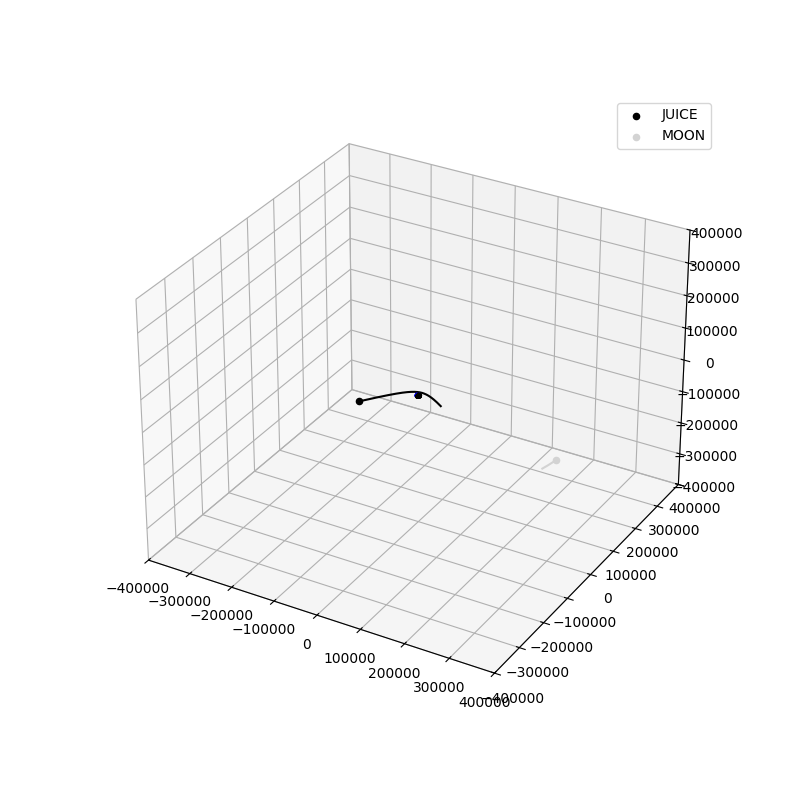

In [4]:
# Plotting orbits

def plot_orbits(kernels, frame, start_date, end_date, center_body, bodies, colors, sun_direction=False):
    """
    Plot the orbits of specified celestial bodies over a given time range.

    Parameters:
    - kernels: List of SPICE kernel files to load.
    - start_date: Start date for the time range (YYYY-MM-DD).
    - end_date: End date for the time range (YYYY-MM-DD).
    - center_body: The body around which the other bodies are plotted.
    - bodies: List of bodies to plot.
    - colors: List of colors for each body.
    """
    radius = center_bodies[center_body]["radius"]
    center_color = center_bodies[center_body]["color"]
    scale = center_bodies[center_body]["scale"]

    # Load SPICE kernels
    for kernel in kernels:
        spice.furnsh(kernel)

    # Convert dates to ephemeris time
    start_epoch = spice.str2et(start_date)
    end_epoch = spice.str2et(end_date)

    # Generate time array
    times = np.linspace(start_epoch, end_epoch, 1000)

    # Create a 3D plot
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Plot the center body (e.g., Sun, Earth, Saturn) as a wireframe
    u = np.linspace(0, 2 * np.pi, 10)
    v = np.linspace(0, np.pi, 10)
    x = radius * np.outer(np.cos(u), np.sin(v))
    y = radius * np.outer(np.sin(u), np.sin(v))
    z = radius * np.outer(np.ones(np.size(u)), np.cos(v))

    if sun_direction:
        sun_pos, _ = spice.spkpos("SUN", times[-1], frame, "NONE", center_body)
        sun_pos = sun_pos / np.linalg.norm(sun_pos)

        dot_products = np.zeros_like(x)
        for i in range(x.shape[0]):
            for j in range(x.shape[1]):
                dot_products[i, j] = np.dot(sun_pos, np.array([x[i, j], y[i, j], z[i, j]]))

        # Normalize dot products to range [0, 1] for colormap
        normalized_dot = (dot_products + 1) / 2

        # Create a custom colormap from center_color to black
        custom_cmap = LinearSegmentedColormap.from_list("custom_cmap", ["black", center_color], N=2)

        # Normalize dot products to range [0, 1] for colormap
        normalized_dot = (dot_products + 1) / 2

        # Apply the custom colormap
        colmap = custom_cmap(normalized_dot)

        # Plot the surface with the colormap
        surf = ax.plot_surface(x, y, z, facecolors=colmap, rstride=1, cstride=1)
        surf.set_facecolor((0, 0, 0, 0))  # Set face color to transparent
    else:
        # Plot the wireframe without Sun direction consideration
        ax.plot_wireframe(x, y, z, color=center_color)

    # Plot the orbits
    for body, color in zip(bodies, colors):
        pos_body, _ = spice.spkpos(body, times, frame, "NONE", center_body)
        ax.plot(pos_body[:, 0], pos_body[:, 1], pos_body[:, 2], color=color)
        ax.scatter(pos_body[-1, 0], pos_body[-1, 1], pos_body[-1, 2], color=color, label=body)

    # Set limits and labels
    ax.set_xlim(-scale, scale)
    ax.set_ylim(-scale, scale)
    ax.set_zlim(-scale, scale)
    ax.legend()

    plt.show()

    spice.kclear()  # Unload all SPICE kernels
    return

center_bodies = {
    "SUN": {"radius": 695700, "color": "yellow", "scale": 4e8},
    "EARTH": {"radius": 6371, "color": "blue", "scale": 4e5},
    "SATURN": {"radius": 58232, "color": "yellow", "scale": 4e6},
    "MERCURY": {"radius": 2439.7, "color": "gray", "scale": 4e4},
    "GANYMEDE": {"radius": 2634.1, "color": "lightgray", "scale": 4e4},
    "JUPITER": {"radius": 69911, "color": "orange", "scale": 4e7},
    "MOON": {"radius": 1737.4, "color": "lightgray", "scale": 4e4},
}

kernels = [
    "../SPICE/JUICE/kernels/mk/juice_plan.tm"
]

frame = "ECLIPJ2000"

start_date = "2024-08-20T19:00:00"
end_date = "2024-08-21T5:00:00"

center_body = "EARTH"

bodies = [
    "JUICE",
    "MOON"
]

colors = [
    "black",
    "lightgray"
]

plot_orbits(kernels, frame, start_date, end_date, center_body, bodies, colors, sun_direction=True)

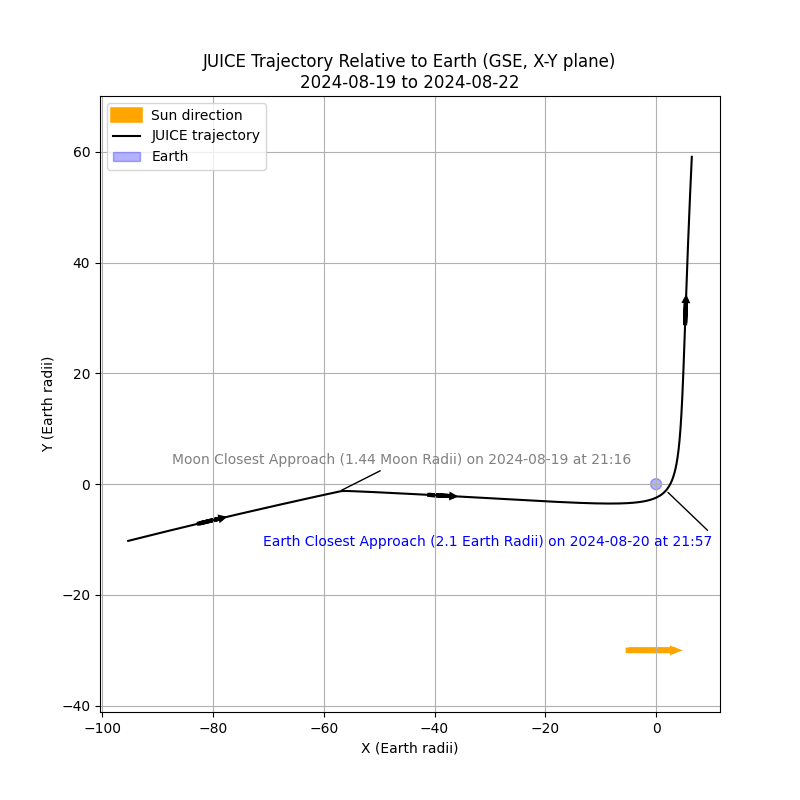

Closest approach to Moon: 2024-08-19 21:15:40.540541+00:00 (ET: 777374209.7233759)
Distance at closest approach: 1.44 Moon radii


In [3]:
# Plot JUICE LEGA in 2D

spice.furnsh("../SPICE/JUICE/kernels/mk/juice_ops.tm")

R_E = 6371.0  # Radius of Earth in km

# Define time range
start_date_gse = "2024-08-19T00:00:00"
end_date_gse = "2024-08-22T00:00:00"
start_et_gse = spice.str2et(start_date_gse)
end_et_gse = spice.str2et(end_date_gse)
times_gse = np.linspace(start_et_gse, end_et_gse, 1000)

# Get JUICE position relative to Earth in GSE coordinates
pos_juice_gse, _ = spice.spkpos("JUICE", times_gse, "GSE", "NONE", "EARTH")

plt.figure(figsize=(8, 8))

# Add arrow for Sun direction (positive X)
plt.arrow(-5, -30, 8, 0, head_width=0.3, head_length=0.4, fc='orange', ec='orange', linewidth=4, label='Sun direction')

plt.annotate('Moon Closest Approach (1.44 Moon Radii) on 2024-08-19 at 21:16', xy=(pos_juice_gse[292, :2]/R_E), textcoords="offset points", xytext=(-120, 20), arrowprops=dict(arrowstyle="-", connectionstyle="arc3"), color = "gray")
plt.annotate('Earth Closest Approach (2.1 Earth Radii) on 2024-08-20 at 21:57', xy=(pos_juice_gse[639, :2]/R_E), textcoords="offset points", xytext=(-290, -40), arrowprops=dict(arrowstyle="-", connectionstyle="arc3", relpos = (1,1)), color = "blue")
arrow_length = 4  # in Earth radii
start_xy = pos_juice_gse[400, :2] / R_E
end_xy = pos_juice_gse[450, :2] / R_E
vec = end_xy - start_xy
vec_norm = vec / np.linalg.norm(vec)  # normalize for arrow length
plt.arrow(start_xy[0], start_xy[1], vec_norm[0]*arrow_length, vec_norm[1]*arrow_length,
          head_width=0.4, head_length=0.4, fc='black', ec='black', linewidth=3)
start_xy = pos_juice_gse[800, :2] / R_E
end_xy = pos_juice_gse[850, :2] / R_E
vec = end_xy - start_xy
vec_norm = vec / np.linalg.norm(vec)  # normalize for arrow length
plt.arrow(start_xy[0], start_xy[1], vec_norm[0]*arrow_length, vec_norm[1]*arrow_length,
          head_width=0.4, head_length=0.4, fc='black', ec='black', linewidth=3)
start_xy = pos_juice_gse[100, :2] / R_E
end_xy = pos_juice_gse[150, :2] / R_E
vec = end_xy - start_xy
vec_norm = vec / np.linalg.norm(vec)  # normalize for arrow length
plt.arrow(start_xy[0], start_xy[1], vec_norm[0]*arrow_length, vec_norm[1]*arrow_length,
          head_width=0.4, head_length=0.4, fc='black', ec='black', linewidth=3)
plt.plot(pos_juice_gse[:, 0]/R_E, pos_juice_gse[:, 1]/R_E, color='black', label='JUICE trajectory')
earth_circle = plt.Circle((0, 0), 1, color='blue', alpha=0.3, label='Earth')
plt.gca().add_patch(earth_circle)
plt.gca().set_aspect('equal')
plt.xlabel('X (Earth radii)')
plt.ylabel('Y (Earth radii)')
plt.title("JUICE Trajectory Relative to Earth (GSE, X-Y plane)\n2024-08-19 to 2024-08-22")
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.show()

pos_moon_gse, _ = spice.spkpos("JUICE", times_gse, "GSE", "NONE", "MOON")

R_M = 1737.4  # Radius of Moon in km

# Find index of closest approach between JUICE and Moon
distances = np.linalg.norm(pos_moon_gse, axis=1)
closest_idx = np.argmin(distances)
closest_time = times_gse[closest_idx]
closest_date = spice.et2datetime(closest_time)
closest_distance = distances[closest_idx]/R_M  # Distance in Moon radii
print(f"Closest approach to Moon: {closest_date} (ET: {closest_time})")
print(f"Distance at closest approach: {closest_distance:.2f} Moon radii")

spice.kclear()

In [3]:
# Calculate angular separation between Earth and JUICE at two specified times

spice.furnsh("../SPICE/JUICE/kernels/mk/juice_ops.tm")

# Define the two dates
date_a = "2024-08-21T16:00:00"
date_b = "2025-03-31T03:00:00"

# Convert to ephemeris time
et_a = spice.str2et(date_a)
et_b = spice.str2et(date_b)

# Get positions relative to the Sun in ECLIPJ2000 frame
pos_earth_a, _ = spice.spkpos("EARTH", et_a, "ECLIPJ2000", "NONE", "SUN")
pos_juice_a, _ = spice.spkpos("JUICE", et_a, "ECLIPJ2000", "NONE", "SUN")
pos_earth_b, _ = spice.spkpos("EARTH", et_b, "ECLIPJ2000", "NONE", "SUN")
pos_juice_b, _ = spice.spkpos("JUICE", et_b, "ECLIPJ2000", "NONE", "SUN")

# Compute angular separations in degrees
sep_a = spice.vsep(pos_earth_a, pos_juice_a) * 180 / np.pi
sep_b = spice.vsep(pos_earth_b, pos_juice_b) * 180 / np.pi

print(f"Angular separation (Earth-JUICE) on 2024-08-21 16:00: {sep_a:.2f} degrees")
print(f"Angular separation (Earth-JUICE) on 2025-03-31 03:00: {sep_b:.2f} degrees")

spice.kclear()  # Unload SPICE kernels

Angular separation (Earth-JUICE) on 2024-08-21 16:00: 0.10 degrees
Angular separation (Earth-JUICE) on 2025-03-31 03:00: 90.30 degrees
